$$
\gdef\trace{\text{Tr}}
\gdef\ket#1{\vert#1\rangle}
\gdef\bra#1{\langle#1\vert}
\gdef\innerprod#1#2{\langle #1 \vert #2 \rangle}
\gdef\ksymm{\mathcal{K}}
$$

### *1. many-body bootstrap*
Solving the groundstate of a general Hamiltonian,
$$
    \min_\rho \trace\left[\rho H\right] \quad \text{s.t.}\quad \rho^\dag=\rho,\ \trace\rho = 1,\ \rho\succcurlyeq 0.
$$
The density matrix $\rho$ is a positive semi-definite (PSD), normalized hermitian matrix. PSD means that for any state $\vert\phi\rangle$,
$$
    \langle\phi\vert\rho\vert\phi\rangle = \sum_i p_i \vert \innerprod{\phi}{\psi_i} \vert^2 \geqslant 0.
$$
Variational methods parameterize $\rho$ with controlled number of parameters, usually scaling with system size in a power law, by adopting wisely a variational ansatz $\rho_\theta$. The original problem is transformed into solving $\rho_\theta$, which yields strictly an upper bound of groundstate energy.

Instead, bootstrap methods enlarge the target space of $\rho$ by relaxing the semi-definite constraints. Rewrite the PSD condition as
$$
    \rho\succcurlyeq 0 \ \iff\ \rho = O^\dag O \ \iff\ \forall S\succcurlyeq 0,\ \trace\left[\rho S\right] \geqslant 0.
$$
One relaxes $S$ to a set of chosen PSD matrix $S_i$ such that the original problem is reduced to an easier one,
$$
    \min_\rho \trace\left[\rho H\right] \quad \text{s.t.}\quad \rho^\dag=\rho;\ \trace\rho = 1;\ \forall\ S_i\succcurlyeq 0,\ \trace\left[\rho S_i\right] \geqslant 0.
$$
This gives strictly a lower bound of groundstate energy. The effectiveness of the method therefore relies on the wise choice of $S_i$ set.

Consider an operator basis $\{O_i\}$, where the Hamiltonian can be represented as a linear combination of $O_i^\dag O_j$. For any operator $O=w_i O_i$, $O^\dag O$ is a PSD operator and we require
$$
    w_i^\ast w_j \trace \left[\rho O_i^\dag O_j\right] \geqslant 0.
$$
If we define $M_{ij}\overset{!}{=}\trace\left[\rho O_i^\dag O_j\right]=\langle O_i^\dag O_j\rangle$, the above positivity constraints state that $M$ is a PSD matrix. Obviously, not all entries of $M$ are independent; symmetries impose powerful constraints that either force elements to vanish or introduce linear dependencies among them. Other basic constraints include:
* $\trace\rho=1$ requires $M_{11} = 1$;

* $\rho^\dag = \rho$ yields $\langle O_i^\dag O_j\rangle^\ast = \langle O_j^\dag O_i\rangle$ such that $M$ is a hermitian.

In practice, one reduces the number of independent moment expectations in $M_{ij}$ using *symmetries* and other physics-insighted constraints and can, in principle, sample them to check whether $M$ is a PSD matrix. This generates a set of feasible regions for the operator spectrum, including the energy. By considering increasingly large operator bases $\{O_i\}$, the result of the optimization problem approaches the exact value, yielding a hierarchy of estimations.

*Complexity:*

$\text{\color{red}todo}$

#### *1.1. Symmetry constraints*
Suppose a Hamiltonian $H$ has a symmetry operation $g$. For a unitary symmetry, $g^{-1}Hg=H$. For an antiunitary symmetry, such as complex conjugation $\ksymm$ or time reversal $\mathcal{T}$, the same formal condition is written as $\ksymm^{-1}H\ksymm=H$ with the important caveat that $\ksymm^{-1} i \ksymm=-i$.

A density matrix $\rho$ is symmetric under $g$ if $g^{-1}\rho g=\rho$ and a thermal density matrix $\rho\sim e^{-\beta H}$ is definitely symmetric. However, assuming that $\rho$ remains symmetric at zero temperature (ground state) is no longer a trivial statement.
$$
    H\ket{\psi_0} = E_0\ket{\psi_0}, \quad H g\ket{\psi_0} = E_0 g\ket{\psi_0}.
$$
If a system has a unique ground state, $g\ket{\psi_0}=e^{i\theta_g}\ket{\psi_0}$. As a result, the density matrix $\rho_0=\ket{\psi_0}\bra{\psi_0}$ is strictly invariant $g^{-1}\rho_0 g = \rho_0$. If the ground state is degenerate (symmetry breaking), an individual pure ground state need not be symmetric. A symmetry operation may map one ground state to another $g\ket{\psi_a}=\ket{\psi_b}$ and a symmetry-broken pure state can have a nonzero expectation value for a symmetry-odd order parameter. However, one can always construct a symmetric ground-state density matrix by averaging over the symmetry orbit,
$$
    \rho_\text{sym} = \frac{1}{\vert G\vert} \sum_{g\in G} g^{-1} \rho g.
$$
This symmetrized density matrix has the same energy as $\rho$. Therefore, for ground-state energy optimization, restricting to symmetric density matrices is usually without loss. The limitation is that symmetry-odd one-point order parameters vanish in $\rho_\text{sym}$, so spontaneous symmetry breaking must be diagnosed through symmetric observables such as two-point correlation functions, or by explicitly relaxing the symmetry constraint.

> [!NOTE]
>
> However, for finite-size systems, this issue should be interpreted carefully.
>
> In a phase that spontaneously breaks a discrete symmetry, the finite-size ground state is often a symmetric “cat” state rather than one of the symmetry-broken states. The symmetry-broken states emerge only in the thermodynamic limit, where a set of symmetry-related low-energy states become degenerate. For a discrete broken symmetry, the splitting between these quasi-degenerate states is typically exponentially small in system size. Consequently, for finite-size ground-state energy bounds, the symmetric-$\rho$ assumption is generally safe. The ordered phase can still be detected through symmetry-invariant quantities such as two-point correlations in the symmetric density matrix.
>
> There are exceptions where finite-size degeneracy is exact, for example due to an exact conserved quantum number, Kramers degeneracy, fine tuning, or topological order. In such cases, an individual pure ground state need not be symmetric, but a symmetric ground-state density matrix can still be constructed by averaging over the degenerate manifold, without changing the energy.
>
> For continuous symmetry breaking, the finite-size precursor is often an Anderson tower of states, where low-energy states in different symmetry sectors collapse onto the ground state algebraically with system size. [?]
>

In the bootstrap SDP, we explicitly assume a $G$-symmetric density matrix. For a pure state, this implies that the state must transform within a definite symmetry sector; however, for a mixed state, it allows the classical mixture of different quantum number sectors. Evaluating moment expectations in a symmetric density matrix yields constraints
$$
    \left\langle O\right\rangle = \trace\left[\rho O\right] = \trace\left[g^{-1}\rho g O\right] = \left\langle g O g^{-1}\right\rangle.
$$
for arbitrary operator $O$. For a discrete symmetry, $g$ enumerates over all group elements. For a continuous unitary symmetry, the same statement can be written infinitesimally. Let $g(\theta)=e^{i\theta Q}$ where $Q$ is Lie generator (symmetry charge). The symmetry condition on the density matrix is equivalently formulated as $\left[\rho, Q\right] = 0$, and we have
$$
    \left\langle O\right\rangle = \left\langle e^{i\theta Q} O e^{-i\theta Q}\right\rangle \overset{\theta\ll 1}{\implies} \left\langle \left[Q,O\right]\right\rangle=0,
$$
which are known as Ward-identity constraints associated with the continuous symmetry. These relations are used to reduce the number of moment variables and to impose linear consistency constraints in the SDP. Specifically, time translation is a continuous unitary transformation generated by the Hamiltonian $U=e^{-iHt}$ such that
$$
    \left\langle \left[H,O\right]\right\rangle = 0,
$$
given stationary states $[\rho,H]=0$. These constraints are often known as stationarity constraints. In practice, a good starting point is to generate constraints from moment operators $O=O_i^\dag O_j$.

Refer to:
* https://arxiv.org/pdf/2406.17844 : extensive benchmark on TFIM

* https://arxiv.org/pdf/2111.13007

* https://github.com/EverettYou/QuantumBootstrap : bootstrap in the krylov space [?]

* https://arxiv.org/pdf/2006.06002, https://arxiv.org/pdf/2410.00810 : Hubbard model

### *2. Transverse-field Ising chain*
$$
    H = \sum_i -J Z_i Z_{i+1} - h X_i.
$$
The $2^N$-dim many-body basis are constructed via the tensor product $\ket{\sigma}=\bigotimes_{i=1}^{N}\vert\sigma_i\rangle$, where each local state $\vert\sigma_i\rangle$ is an eigenstate of $Z_i$ with eigenvalue $\sigma_i$. A general state $\ket{\psi}$ is a linear combination of $\ket{\sigma}$, $\ket{\psi}=\sum_\sigma a_\sigma\ket{\sigma}$, usually denoted as a $2^N$-dim column vector $(\dots, a_\sigma, \dots)^T$.

#### *2.0. Symmetry revisited*
General symmetries can be divided into basically two classes, unitary symmetries
$$
    \ket{\psi} \to U \ket{\psi},
$$
and anti-unitary symmetries
$$
    \ket{\psi} \to U \ksymm\ket{\psi} = U\ket{\psi}^\ast,
$$
where $\ksymm$ denotes the operation of complex conjugation and $\ksymm^2=1$. $\ksymm$ is anti-unitary because first it is anti-linear
$$
    \ksymm\ket{\psi} \overset{!}{=} \ket{\psi}^\ast = \sum_\sigma a_\sigma^\ast \ket{\sigma}.
$$
It satisfies
$$
    \langle\ksymm\phi\vert\ksymm\psi\rangle = \innerprod{\phi}{\psi}^\ast,
$$
which is consistent with *Wigner theorem* stating that two states transformed under the symmetry should have a preserved inner product amplitude. The Wigner theorem also forbids any mixed operation, $\ket{\psi} \to U_1 \ket{\psi} + U_2\ksymm \ket{\psi}$,to be a symmetry. Equivalently, in the Heisenberg picture, an operator $O$ transforms as $O \to U^\dag O U$ under unitary symmetries and as $O \to \ksymm U^\dag O U \ksymm$ under anti-unitary symmetries, with the operators applied sequentially from right to left. The anti-unitary operation $\ksymm O \ksymm$ is understood by acting it on an arbitrary state, which yields
$$
    \ket{\ksymm O \ksymm \psi}_{\sigma'}
    = \sum_\sigma \left(O_{\sigma'\sigma} a_\sigma^\ast \ket{\sigma}\right)^\ast
    = \sum_\sigma O^\ast_{\sigma'\sigma} a_\sigma \ket{\sigma}
    = \ket{O^\ast \psi}_{\sigma'},
$$
and $\ksymm O \ksymm = O^\ast$.

#### *2.1. $\ksymm$-symmetry*
For the transverse-field Ising (TFI) chain, we consider the simplest anti-unitary symmetry $\ksymm$. The Hamiltonian in our chosen basis $\{\ket{\sigma}\}$ is expressed as a purely real matrix $H^\ast=H$, and is hence invariant under complex conjugation $\ksymm$,
$$
    \ksymm H \ksymm = H.
$$
Assuming $\ket{\psi}$ is an eigenstate of $H$, we have
$$
    H \ket{\psi} = \ksymm H \ksymm \ket{\psi} = E \ket{\psi} \implies H \ket{\psi}^\ast = E \ket{\psi}^\ast.
$$
Therefore, $\ket{\psi}$ and $\ket{\psi}^\ast$ have the same energy. The logic is that if $\ket{\psi}$ and $\ket{\psi}^\ast$ are linearly independent, we can construct
$$
    \ket{\psi_+} \sim \ket{\psi} + \ket{\psi}^\ast, \quad
    \ket{\psi_-} \sim i \left(\ket{\psi} - \ket{\psi}^\ast\right),
$$
and both $\ket{\psi_\pm}$ are purely real-valued, $\ksymm$-even states. Otherwise, if $\ket{\psi}$ and $\ket{\psi}^\ast$ are the same state, then $\ket{\psi}$ itself is real-valued.  This guarantees that all energy eigenstates can be safely chosen as purely real-valued and $\ksymm$-even states without loss of generality. Note this is equivalent to stating that  the density matrix $\rho = \sum_n p_n \ket{\psi_n}\langle\psi_n\vert$ can be chosen as real-valued, symmetric and $\ksymm$-even matrices, where $\ket{\psi_n}$ can be any normalized $\ksymm$-even pure state. Below we will stick to the Heisenberg picture and assume a $\ksymm$-even density matrix $\rho_+$ throughout. This extends our discussions to mixed states such as thermal density matrix $\rho\sim e^{-\beta H}$ with very little effort.

To proceed, we categorize the operators based on their parity under $\ksymm$ into $\ksymm$-even and $\ksymm$-odd classes.
$$
    O = \underbrace{\frac{1}{2}\left(O + O^\ast\right)}_{O_+} + \underbrace{\frac{1}{2}\left(O - O^\ast\right)}_{O_-},
$$
and $\ksymm O_\pm\ksymm = O_\pm^\ast = \pm O_\pm$. The Hamiltonian $H$ is obviously $\ksymm$-even. Also, the $\ksymm$-parity is multiplicative, following a $\mathbb{Z}_2$ grading algebra: $O_\pm O_\pm=O_+$ and $O_\pm O_\mp=O_-$. For TFI chain, we consider a set of operators $\{O_i\}$ and each $O_i$ is a Pauli string $O=\bigotimes_{i=1}^N \sigma^\alpha_i$. $\ksymm$ symmetry applies on such a Pauli string as
$$
    \ksymm \left(\bigotimes_{i=1}^N \sigma^\alpha_i\right) \ksymm = \bigotimes_{i=1}^N \ksymm \sigma^\alpha_i \ksymm.
$$
Hence to determine whether a Pauli string is $K$-even or $K$-odd is simply to count the number of $Y$ operators it contains, $\ksymm O\ksymm = (-1)^{N_y} O$. Note that given a $\ksymm$-even $\rho_+$,
$$
    \langle O_\pm\rangle
    = \trace \left[\rho_+ O_\pm\right]
    = \pm \trace \left[\rho_+ \ksymm O_\pm \ksymm\right]
    = \pm \trace \left[\rho_+ O_\pm^\ast \right]
    = \pm \langle O_\pm\rangle^\ast.
$$
Therefore, $\langle O_+\rangle$ is real and $\langle O_-\rangle$ is purely imaginary with $O_\pm$ here not necessarily a hermitian.

We will show that the presence of $\ksymm$-symmetry facilitates the bootstrap calculation in the following aspects:

* It reveals the intrinsic structure of the moment matrix $M_{ij}=\langle O^\dag_i O_j\rangle$ such that we can transform it into a real-valued matrix. Assuming that we divide the Pauli string basis $\{O_i\}$ by class $\{O_+,O_-\}$, the moment matrix is expressed into a block form based on our discussion above
  $$
        M = \begin{pmatrix}M_1 & iM_3\\[5pt]-iM_3^T & M_2\\\end{pmatrix},
  $$
  where $M_1$ and $M_2$ are real symmetric matrices and $M_3$ a real matrix. This intrinsic structure of $M$ facilitates SDP calculations if we further consider a unitary transformation
  $$
        U = \begin{pmatrix}I & 0\\ 0 & iI\\\end{pmatrix}, \quad
        \tilde{M} = U^\dag M U = \begin{pmatrix}M_1 & -M_3\\[5pt]-M_3^T & M_2\\\end{pmatrix}.
  $$
  Now $\tilde{M}$ is a real symmetric matrix and by construction $M\succcurlyeq 0$ is equivalent to $\tilde{M}\succcurlyeq 0$. Since the backend SDP solvers are fundamentally designed to operate natively on real numbers, the bootstrap calculation shall benefit significantly from condensing $M$ from a hermitian to a symmetric matrix.

* It reduces the number of moment variables. In bootstrap, we identify the expectation values of Pauli strings $\mathcal{O}_{ij}$, associated to moment operators $O^\dag_i O_j$, as moment variables. A Pauli string is hermitian by nature, while it may differ from $O^\dag_i O_j$ by a pure real or imaginary factor and may have opposite parity. Consider a $\ksymm$-odd Pauli string, its expectation is purely complex given a symmetric $\rho_+$. And because Pauli string is a hermitian, its expectation must be real. This yields that the expectation of $K$-odd $\mathcal{O}_{ij}$ must vanish and we only need to consider $K$-even ones as moment variables.

* It implies that nontrivial stationarity constraints, $\langle[H,O]\rangle=0$ can only be generated from $K$-odd Pauli strings $\mathcal{O}_{ij}$. By definition, $[H, \mathcal{O}_{ij}]$ shares identical parity with $\mathcal{O}_{ij}$ and is anti-hermitian as long as $\mathcal{O}_{ij}$ is hermitian. Furthermore, if $\mathcal{O}_{ij}$ is $\ksymm$-even, we deduce $\langle[H, \mathcal{O}_{ij}]\rangle \in \mathbb{R}$ from the fact that $[H, \mathcal{O}_{ij}]$ is $\ksymm$-even. However, the anti-hermiticity of $[H, \mathcal{O}_{ij}]$ ensures its expectation value to be purely imaginary. And we conclude $\langle[H, \mathcal{O}_{ij}]\rangle \equiv 0$ from deduction. As a result, only $\ksymm$-odd $\mathcal{O}_{ij}$ generates valid stationarity constraints.

For TFI chain and general real-matrix Hamiltonians under certain basis, the assumption of real symmetric $\rho$ is physically natural. However, if the $\ksymm$-symmetry is spontaneously broken, e.g. by a non-trivial spin current, it can not see the symmetry-odd one-point order parameter, but the ordered phase may still be detected in symmetry-even two-point correlations. How to bootstrap dynamics? (find refs.)

#### *2.2. Symmetry blocks*
...

#### *2.3. Benchmark with ED*

ED        time=0.230s    E_0/L=-1.27528715
basis0    time=0.186s    E_0/L=-1.30958350   status=optimal 
basis1    time=16.201s   E_0/L=-1.28185469   status=optimal 
basis2    time=74.806s   E_0/L=-1.27824403   status=optimal 


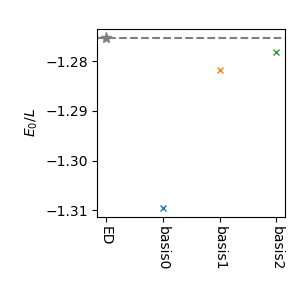

In [1]:
%reset -f
from ed.ising import gs as ed_gs
from ising.ising import IsingParams, IsingCompiler
from sdp import SDPSolver

import time
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib widget

def bootstrap_gs(L, J, h, basis, eps=1e-4, max_iters=5000):
    compiler = IsingCompiler(IsingParams(L=L, J=J, h=h))
    compiler.compile(basis)
    solver = SDPSolver()
    solver.build(compiler.sdp_data())
    value = solver.solve(solver='SCS', eps=eps, max_iters=max_iters)
    return value, compiler.summary(), solver.summary()


L = 16
J = 1.
h = 1.

basis0 = ['I', 'X', 'Y', 'Z', 'ZZ']
basis1 = basis0 + ['XX', 'YY', 'XZ', 'XY', 'YX', 'YZ', 'ZX', 'ZY', 'IX', 'IY', 'IZ']
basis2 = basis1 + ['XXX', 'XXY', 'XXZ', 'XYX', 'XYY', 'XYZ', 'XZX', 'XZY', 'XZZ']
bases = {
    'basis0': basis0,
    'basis1': basis1,
    'basis2': basis2,
}
eps = 1e-4
max_iters = 10_000

fig, ax = plt.subplots(1, 1, figsize=(3,3))

t0 = time.perf_counter()
e0 = ed_gs(L, J=J, h=h)
dt = time.perf_counter() - t0
print(
    f'{"ED":<10s}'
    f'{f"time={dt:.3f}s":<15s}'
    f'{f"E_0/L={e0/L:.8f}":<15s}'
)
ax.plot(['ED'], [e0/L], marker='*', markersize=8, color='tab:grey')
ax.axhline(y=e0/L, color='tab:grey', linestyle='dashed')

for name, basis in bases.items():
    t0 = time.perf_counter()
    e0_lower, compiler_summary, solver_summary = bootstrap_gs(
        L, J, h, basis, eps=eps, max_iters=max_iters,
    )
    dt = time.perf_counter() - t0
    print(
        f'{name:<10s}'
        f'{f"time={dt:.3f}s":<15s}'
        f'{f"E_0/L={e0_lower/L:.8f}":<20s}'
        f'{f"status={solver_summary["status"]}":<15s}'
    )
    ax.plot([name], [e0_lower/L], marker='x', markersize=5, markerfacecolor='none')

ax.tick_params(axis='x', labelrotation=270)
ax.set_ylabel(r'$E_0/L$')

ax.set_box_aspect(1)
fig.tight_layout()

### *3. Hubbard chain*
$$
    H = -t \sum_{i,\sigma} \left(c^\dag_{i,\sigma} c_{i+1,\sigma} + c^\dag_{i+1,\sigma} c_{i,\sigma}\right) + U \sum_i \left(n_{i\uparrow}-\frac{1}{2}\right) \left(n_{i\downarrow}-\frac{1}{2}\right).
$$
Consider Majorana fermion operators, $\gamma_1=c^\dag+c$ and $\gamma_2=i(c^\dag-c)$, where $\gamma_a$ are hermitian and obey the Clifford algebra $\{\gamma_a,\gamma_b\}=2\delta_{ab}$. The local Hilbert space of Hubbard chain is 4-dim such that the local operator space is 16-dim, spanned by all Majorana monomials generated from the four local Majorana modes $\gamma_{i,\sigma}^a$. In [hubbard/hubbard.py](hubbard/hubbard.py), the local operator basis is encoded as a 4-bit nibble. In terms of Majorana fermions, the Hubbard chain becomes
$$
    H = \frac{t}{2} \sum_{i,\sigma} \gamma^T_{i,\sigma} Y \gamma_{i+1,\sigma} - \frac{U}{4} \sum_{i} \gamma^1_{i\uparrow} \gamma^2_{i\uparrow} \gamma^1_{i\downarrow} \gamma^2_{i\downarrow}.
$$

#### *3.1. $U(1)$ symmetry and Fermion parity*
The particle number $N$ is the conserved charge generating the global $U(1)$ symmetry, $U(\theta)=e^{i\theta N}$. It acts on fermion operators as
$$
    U(\theta)c U(\theta)^{-1}=e^{-i\theta} c, \quad U(\theta)c^\dag U(\theta)^{-1}=e^{i\theta}c^\dag.
$$
For Majorana operators,
$$
    U(\theta)
    \begin{pmatrix}\gamma_1\\ \gamma_2\end{pmatrix}
    U(\theta)^{-1}
    = \begin{pmatrix}
     \cos\theta & \sin\theta\\
    -\sin\theta & \cos\theta
    \end{pmatrix}
    \begin{pmatrix}\gamma_1\\ \gamma_2\end{pmatrix}.
$$
The fermion parity operator $P=(-1)^N$ is the special group element at $\theta=\pi$. Thus fermion parity is the $\mathbb{Z}_2$ subgroup of the particle-number $U(1)$ symmetry. Fermion parity can remain a symmetry even when the full $U(1)$ symmetry is absent, as in pairing Hamiltonians where particle number changes by pairs.

The superselection principle claims that coherent superpositions between opposite parity sectors are not physical (while classical mixtures of opposite-parity states are permitted). For example, BCS wave function mixes states with different particle numbers yet still with same parity, and there is no spontaneous $P$-broken states observed in laboratory. Equivalently, every physical $\rho$ must commute with fermion parity, $[\rho,P]=0$. In our case, each Majorana fermion is parity-odd, $P^{-1}\gamma_a P=-\gamma_a$. Therefore a Majorana monomial $\Gamma=\prod\gamma_i^a$ with degree $q$ transforms as $P^{-1} \Gamma P = (-1)^q \Gamma$. As a result, odd-degree monomial moments must have vanishing expectation value according to the parity constraint,
$$
    \left\langle \Gamma\right\rangle = \left\langle P^{-1} \Gamma P\right\rangle = 0.
$$

Moreover, assuming the full $U(1)$ symmetry $[\rho,N]=0$ gives stronger Ward identities $\langle[N,\Gamma]\rangle=0$, which remove all operators carrying nonzero particle-number charge, including pairing moments such as $\langle c_i c_j\rangle$. Since Majorana moments are generally not eigenoperators of $U(1)$ operations, the $U(1)$ selection rule is not simply implemented by discarding individual Majorana monomials. Instead, the $U(1)$ constraints can be generated by directly computing the Ward identities, analogously to stationarity constraints.

For the spinful Hubbard Hamiltonian, the spin-up and spin-down particle numbers are separately conserved. Therefore we actually have a $U_\uparrow(1)\times U_\downarrow(1)$ symmetry, and also $P_\uparrow\times P_\downarrow$. The parity constraints eliminate monomial moments containing an odd number of Majoranas for each spin, and the full continuous symmetries yield Ward identities $\left\langle[N_\sigma, \Gamma]\right\rangle=0$ for each spin $\sigma$.

Note that $[\rho,N]=0$ only forbids coherent superpositions between different charge sectors. And it still permits a classical mixture of states with different particle numbers. To fix the filling and compare directly with ED, we further impose $\left\langle N\right\rangle=N_0$ and $\left\langle(N-N_0)^2\right\rangle=0$.

#### *3.2. Spin $SU(2)$*

#### *3.3. Time reversion*

#### *3.4. Particle-hole and $\eta$-pairing at half-filling*


#### *3.5. Benchmark with ED*

ED                  time=0.009s    E_0/L=-1.61145103
d4s1d0    16        time=0.444s    E_0/L=-1.68816733   status=optimal 
d2s2d1    27        time=3.191s    E_0/L=-1.70922673   status=optimal 
d2s2d2    43        time=17.341s   E_0/L=-1.66972123   status=optimal 
d2s2d3    53        time=17.567s   E_0/L=-1.64671866   status=optimal 


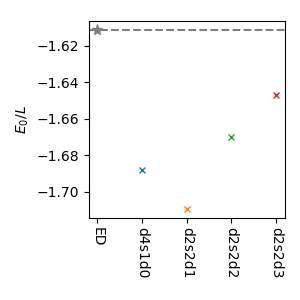

In [2]:
%reset -f
from ed.hubbard import gs as ed_gs
from hubbard.hubbard import HubbardParams, HubbardCompiler, load_basis_reprs
from sdp import SDPSolver

import time
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib widget

def bootstrap_gs(params, basis_reprs, eps=1e-4, max_iters=5000):
    compiler = HubbardCompiler(params)
    compiler.compile(basis_reprs)
    solver = SDPSolver()
    solver.build(compiler.sdp_data())
    value = solver.solve(solver='SCS', eps=eps, max_iters=max_iters)
    return value, compiler.summary(), solver.summary()


L = 6
t = 1.
U = 4.
n_particles = L
params = HubbardParams(L=L, t=t, U=U, n_particles=n_particles)

bases = {
    'd4s1d0': load_basis_reprs(L, max_degree=4, max_support=1, max_diameter=0),
    'd2s2d1': load_basis_reprs(L, max_degree=2, max_support=2, max_diameter=1),
    'd2s2d2': load_basis_reprs(L, max_degree=2, max_support=2, max_diameter=2),
    'd2s2d3': load_basis_reprs(L, max_degree=2, max_support=2, max_diameter=3),
}
eps = 1e-4
max_iters = 5_000

fig, ax = plt.subplots(1, 1, figsize=(3,3))

t0 = time.perf_counter()
e0 = ed_gs(L, t=t, U=U, n_particles=n_particles)
dt = time.perf_counter() - t0
print(
    f'{"ED":<10s}'
    f'{"":<10s}'
    f'{f"time={dt:.3f}s":<15s}'
    f'{f"E_0/L={e0/L:.8f}":<15s}'
)
ax.plot(['ED'], [e0/L], marker='*', markersize=8, color='tab:grey')
ax.axhline(y=e0/L, color='tab:grey', linestyle='dashed')

for name, basis_reprs in bases.items():
    t0 = time.perf_counter()
    print(
        f'{name:<10s}'
        f'{len(basis_reprs):<10d}',
        end=''
    )
    e0_lower, compiler_summary, solver_summary = bootstrap_gs(
        params, basis_reprs, eps=eps, max_iters=max_iters,
    )
    dt = time.perf_counter() - t0
    print(
        f'{f"time={dt:.3f}s":<15s}'
        f'{f"E_0/L={e0_lower/L:.8f}":<20s}'
        f'{f"status={solver_summary['status']}":<15s}'
    )
    ax.plot([name], [e0_lower/L], marker='x', markersize=5, markerfacecolor='none')

ax.tick_params(axis='x', labelrotation=270)
ax.set_ylabel(r'$E_0/L$')

ax.set_box_aspect(1)
fig.tight_layout()